In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install joblib
!pip install gradio
!pip install tqdm
!pip install plotly

In [320]:
import pandas, numpy, sklearn, matplotlib, seaborn, xgboost, gradio, joblib
print("✅ All packages installed!")

✅ All packages installed!


In [321]:
import pandas as pd
import numpy as np
import os

In [322]:
# Set path to your data folder
DATA_PATH = '../data/data-science-nigeria-credit-risk-prediction'

# List all files in data folder to see what you have
print("Files in data folder:")
print(os.listdir(DATA_PATH))

Files in data folder:
['SampleSubmission.csv', 'testdemographics.csv', 'testperf.csv', 'testprevloans.csv', 'traindemographics.csv', 'trainperf.csv', 'trainprevloans.csv']


In [323]:
# You only need training data for EDA, feature engineering, and model training (Steps 1-12)

# Test files are only used at the end (Step 14 - deployment) for making predictions

# Load the 3 training files
train_perf = pd.read_csv(DATA_PATH + '/trainperf.csv')
train_demo = pd.read_csv(DATA_PATH + '/traindemographics.csv')
train_prev = pd.read_csv(DATA_PATH + '/trainprevloans.csv')

print(f"trainperf shape: {train_perf.shape}")
print(f"traindemographics shape: {train_demo.shape}")
print(f"trainprevloans shape: {train_prev.shape}")

trainperf shape: (4368, 10)
traindemographics shape: (4346, 9)
trainprevloans shape: (18183, 12)


In [324]:
# Checking performance data (has the target)

print(f'Performance Data')
print(f'\n shape: \n {train_perf.shape}\n')
print(f'\n Types: \n {train_perf.dtypes}\n')
print(f'\n 1st 3 for head: \n {train_perf.head(3)}\n')
 

Performance Data

 shape: 
 (4368, 10)


 Types: 
 customerid        object
systemloanid       int64
loannumber         int64
approveddate      object
creationdate      object
loanamount       float64
totaldue         float64
termdays           int64
referredby        object
good_bad_flag     object
dtype: object


 1st 3 for head: 
                          customerid  systemloanid  loannumber  \
0  8a2a81a74ce8c05d014cfb32a0da1049     301994762          12   
1  8a85886e54beabf90154c0a29ae757c0     301965204           2   
2  8a8588f35438fe12015444567666018e     301966580           7   

                 approveddate                creationdate  loanamount  \
0  2017-07-25 08:22:56.000000  2017-07-25 07:22:47.000000     30000.0   
1  2017-07-05 17:04:41.000000  2017-07-05 16:04:18.000000     15000.0   
2  2017-07-06 14:52:57.000000  2017-07-06 13:52:51.000000     20000.0   

   totaldue  termdays referredby good_bad_flag  
0   34500.0        30        NaN          Good  
1   17250.0 

In [325]:
# Check demographics data
print(f'Demographic Data')
print(f'\n shape: \n {train_demo.shape}\n')
print(f'\n Types: \n {train_demo.dtypes}\n')
print(f'\n 1st 3 for head: \n {train_demo.head(3)}\n')

Demographic Data

 shape: 
 (4346, 9)


 Types: 
 customerid                     object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
dtype: object


 1st 3 for head: 
                          customerid                   birthdate  \
0  8a858e135cb22031015cbafc76964ebd  1973-10-10 00:00:00.000000   
1  8a858e275c7ea5ec015c82482d7c3996  1986-01-21 00:00:00.000000   
2  8a858e5b5bd99460015bdc95cd485634  1987-04-01 00:00:00.000000   

  bank_account_type  longitude_gps  latitude_gps bank_name_clients  \
0           Savings       3.319219      6.528604           GT Bank   
1           Savings       3.325598      7.119403     Sterling Bank   
2           Savings       5.746100      5.563174     Fidelity Bank   

  bank_branch_clients e

In [326]:
# Check Previous Loans data
print(f'TRAINPREVLOANS (Previous Loans)')
print(f'\n shape: \n {train_prev.shape}\n')
print(f'\n Types: \n {train_prev.dtypes}\n')
print(f'\n 1st 3 for head: \n {train_prev.head(3)}\n')

TRAINPREVLOANS (Previous Loans)

 shape: 
 (18183, 12)


 Types: 
 customerid          object
systemloanid         int64
loannumber           int64
approveddate        object
creationdate        object
loanamount         float64
totaldue           float64
termdays             int64
closeddate          object
referredby          object
firstduedate        object
firstrepaiddate     object
dtype: object


 1st 3 for head: 
                          customerid  systemloanid  loannumber  \
0  8a2a81a74ce8c05d014cfb32a0da1049     301682320           2   
1  8a2a81a74ce8c05d014cfb32a0da1049     301883808           9   
2  8a2a81a74ce8c05d014cfb32a0da1049     301831714           8   

                 approveddate                creationdate  loanamount  \
0  2016-08-15 18:22:40.000000  2016-08-15 17:22:32.000000     10000.0   
1  2017-04-28 18:39:07.000000  2017-04-28 17:38:53.000000     10000.0   
2  2017-03-05 10:56:25.000000  2017-03-05 09:56:19.000000     20000.0   

   totaldue  termday

In [327]:
# Find the column that links these tables
print('Checking for common ID columns')
print(f'\n trainperf columns: {train_perf.columns.tolist()} \n')
print(f'trainemo columns: {train_demo.columns.tolist()} \n')
print(f'trainprev columns: {train_prev.columns.tolist()}')

Checking for common ID columns

 trainperf columns: ['customerid', 'systemloanid', 'loannumber', 'approveddate', 'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby', 'good_bad_flag'] 

trainemo columns: ['customerid', 'birthdate', 'bank_account_type', 'longitude_gps', 'latitude_gps', 'bank_name_clients', 'bank_branch_clients', 'employment_status_clients', 'level_of_education_clients'] 

trainprev columns: ['customerid', 'systemloanid', 'loannumber', 'approveddate', 'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate', 'referredby', 'firstduedate', 'firstrepaiddate']


In [328]:
#Find the common columns
common_cols = set(train_perf.columns) & set(train_demo.columns) & set(train_prev.columns)
print(f"\nCommon columns across all 3 files: {common_cols}")


Common columns across all 3 files: {'customerid'}


In [329]:
# Merge on the common ID column ('customer_id')
id_col = list(common_cols)[0]  # Take the first common column
print(id_col)


customerid


In [330]:
#Merge all the 3 files
df = train_perf.merge(train_demo, on = id_col, how = 'left')
df = df.merge(train_prev, on = id_col, how = 'left')
print(f"Final merged dataset shape: {df.shape} \n")
print(f"Columns: {df.columns.tolist()} \n")
df.head()


Final merged dataset shape: (18212, 29) 

Columns: ['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x', 'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x', 'referredby_x', 'good_bad_flag', 'birthdate', 'bank_account_type', 'longitude_gps', 'latitude_gps', 'bank_name_clients', 'bank_branch_clients', 'employment_status_clients', 'level_of_education_clients', 'systemloanid_y', 'loannumber_y', 'approveddate_y', 'creationdate_y', 'loanamount_y', 'totaldue_y', 'termdays_y', 'closeddate', 'referredby_y', 'firstduedate', 'firstrepaiddate'] 



,customerid,systemloanid_x,loannumber_x,approveddate_x,creationdate_x,loanamount_x,totaldue_x,termdays_x,referredby_x,good_bad_flag,...,loannumber_y,approveddate_y,creationdate_y,loanamount_y,totaldue_y,termdays_y,closeddate,referredby_y,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,2.0,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30.0,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,9.0,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30.0,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,8.0,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30.0,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,10.0,2017-06-01 13:34:30.000000,2017-06-01 12:34:21.000000,20000.0,24500.0,30.0,2017-06-25 15:24:06.000000,NaN,2017-07-03 00:00:00.000000,2017-06-25 15:13:56.000000
4,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,...,11.0,2017-06-28 10:58:34.000000,2017-06-28 09:58:25.000000,20000.0,24500.0,30.0,2017-07-25 08:14:36.000000,NaN,2017-07-31 00:00:00.000000,2017-07-25 08:04:27.000000


In [331]:
target_col = 'good_bad_flag'

df['target_col'] = df['good_bad_flag']
print(df.columns)

Index(['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x',
       'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x',
       'referredby_x', 'good_bad_flag', 'birthdate', 'bank_account_type',
       'longitude_gps', 'latitude_gps', 'bank_name_clients',
       'bank_branch_clients', 'employment_status_clients',
       'level_of_education_clients', 'systemloanid_y', 'loannumber_y',
       'approveddate_y', 'creationdate_y', 'loanamount_y', 'totaldue_y',
       'termdays_y', 'closeddate', 'referredby_y', 'firstduedate',
       'firstrepaiddate', 'target_col'],
      dtype='object')


In [332]:


print(f"\nTarget distribution:")
print(df[target_col].value_counts())
print(f"\nPercentage:")
print(df[target_col].value_counts(normalize=True) * 100)


Target distribution:
good_bad_flag
Good    14840
Bad      3372
Name: count, dtype: int64

Percentage:
good_bad_flag
Good    81.484735
Bad     18.515265
Name: proportion, dtype: float64


In [333]:
miss = df.isnull().sum()
missing_pct = miss * 100 / len(df)
report = pd.DataFrame({
    'missing data': miss,
    'missing_pct': missing_pct
}).sort_values(by = 'missing_pct', ascending = False)
print(f'Missing data: \n {report}\n')

Missing data: 
                             missing data  missing_pct
bank_branch_clients                18105    99.412475
referredby_y                       17184    94.355370
referredby_x                       17184    94.355370
level_of_education_clients         14745    80.963101
employment_status_clients           5877    32.269932
bank_account_type                   4514    24.785855
bank_name_clients                   4514    24.785855
latitude_gps                        4514    24.785855
longitude_gps                       4514    24.785855
birthdate                           4514    24.785855
approveddate_y                         9     0.049418
loanamount_y                           9     0.049418
totaldue_y                             9     0.049418
termdays_y                             9     0.049418
closeddate                             9     0.049418
creationdate_y                         9     0.049418
firstduedate                           9     0.049418
firstrepaidd

In [334]:

dups = df.duplicated().sum()
print(f'\nDuplicates in Train_demo: {dups} \n')

print(df.describe())


Duplicates in Train_demo: 20 

       systemloanid_x  loannumber_x  loanamount_x    totaldue_x    termdays_x  \
count    1.821200e+04  18212.000000  18212.000000  18212.000000  18212.000000   
mean     3.019804e+08      8.373215  25656.984406  29789.477026     33.353009   
std      1.342862e+04      4.284116  12649.336773  13818.368500     14.707205   
min      3.019585e+08      2.000000  10000.000000  10000.000000     15.000000   
25%      3.019681e+08      5.000000  10000.000000  13000.000000     30.000000   
50%      3.019793e+08      8.000000  30000.000000  33000.000000     30.000000   
75%      3.019930e+08     11.000000  40000.000000  44000.000000     30.000000   
max      3.020040e+08     27.000000  60000.000000  68100.000000     90.000000   

       longitude_gps  latitude_gps  systemloanid_y  loannumber_y  \
count   13698.000000  13698.000000    1.820300e+04  18203.000000   
mean        4.481972      7.291344    3.018396e+08      4.188211   
std         8.638033      3.435619

In [335]:
# Column Descriptions - SuperLender Dataset

## A) Demographic Data (traindemographics.csv)

# A) Demographic Data (traindemographics.csv)
# Column	What It Represents
# customerid	Unique ID number for each customer (links all tables together)
# birthdate	Customer's date of birth
# bank_account_type	Type of bank account the customer has (e.g., savings, current)
# longitude_gps	GPS longitude coordinate of customer's location
# latitude_gps	GPS latitude coordinate of customer's location
# bank_name_clients	Name of the customer's bank
# bank_branch_clients	Which branch of the bank the customer uses (often missing)
# employment_status_clients	Customer's employment type (employed, self-employed, unemployed, etc.)
# level_of_education_clients	Customer's highest education level (primary, secondary, tertiary)
# B) Performance Data (trainperf.csv) - TARGET DATA
# Column	What It Represents
# customerid	Unique ID number for each customer (links all tables together)
# systemloanid	Unique ID for this specific loan (one customer can have multiple loans)
# loannumber	The number/identifier of the loan we need to predict
# approveddate	Date when the loan was approved
# creationdate	Date when the loan application was created
# loanamount	Amount of money borrowed
# totaldue	Total amount customer must repay (loan + interest + fees)
# termdays	How long the customer has to repay the loan (in days)
# referredby	customerID of who referred this customer (blank if not referred)
# good_bad_flag	TARGET VARIABLE - 1 = good (repaid on time), 0 = bad (defaulted)
# ________________________________________
# C) Previous Loans Data (trainprevloans.csv)
# Column	What It Represents
# customerid	Unique ID number for each customer (links all tables together)
# systemloanid	Unique ID for each previous loan (different from current loan ID)
# loannumber	Number/identifier of the previous loan
# approveddate	Date when previous loan was approved
# creationdate	Date when previous loan application was created
# loanamount	Amount borrowed in previous loan
# totaldue	Total amount due for previous loan (loan + interest + fees)
# termdays	Repayment period for previous loan (in days)
# closeddate	Date when previous loan was fully repaid/closed
# referredby	customerID of who referred customer for previous loan (blank if not referred)
# firstduedate	Date of first payment due (for loans with multiple payments)
# firstrepaiddate	Actual date customer made their first payment


UNIVARIATE ANALYSES

In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(df.dtypes)

customerid                     object
systemloanid_x                  int64
loannumber_x                    int64
approveddate_x                 object
creationdate_x                 object
loanamount_x                  float64
totaldue_x                    float64
termdays_x                      int64
referredby_x                   object
good_bad_flag                  object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
systemloanid_y                float64
loannumber_y                  float64
approveddate_y                 object
creationdate_y                 object
loanamount_y                  float64
totaldue_y                    float64
termdays_y                    float64
closeddate                     object
referredby_y

In [337]:
# Convert target_col from 'Good'/'Bad' to 1/0
df['target_col'] = df['target_col'].map({'Good': 1, 'Bad': 0})

# Check the conversion
print("target_col conversion:")
print(df['target_col'].value_counts())
print(f"\nUnique values: {df['target_col'].unique()}")
print(df.dtypes)

target_col conversion:
target_col
1    14840
0     3372
Name: count, dtype: int64

Unique values: [1 0]
customerid                     object
systemloanid_x                  int64
loannumber_x                    int64
approveddate_x                 object
creationdate_x                 object
loanamount_x                  float64
totaldue_x                    float64
termdays_x                      int64
referredby_x                   object
good_bad_flag                  object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
systemloanid_y                float64
loannumber_y                  float64
approveddate_y                 object
creationdate_y                 object
loanamount_y                  float64
totaldue_y            

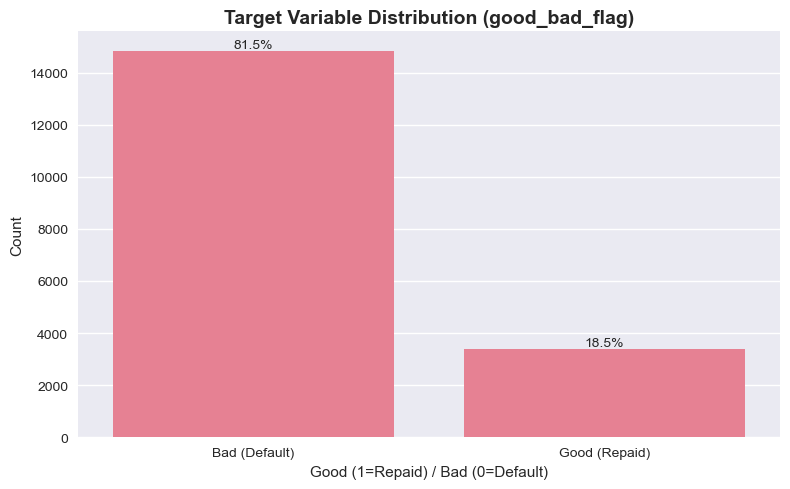


📊 Class Balance: 18.5% Good, 81.5% Bad
⚠️  Dataset is imbalanced - will need stratify=y and use F1/Recall metrics


In [338]:
# Create bar chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=target_col, data=df)
plt.title('Target Variable Distribution (good_bad_flag)', fontsize=14, fontweight='bold')
plt.xlabel('Good (1=Repaid) / Bad (0=Default)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Bad (Default)', 'Good (Repaid)'])

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150)
plt.show()

# Conclusion
print(f"\n📊 Class Balance: {target_pct.iloc[1]:.1f}% Good, {target_pct.iloc[0]:.1f}% Bad")
if target_pct.min() < 30:
    print("⚠️  Dataset is imbalanced - will need stratify=y and use F1/Recall metrics")
else:
    print("✅ Dataset is relatively balanced")

In [339]:
print(f'Before : {df.shape}')

# 1. Drop unnecessary columns (IDs, dates)
cols_to_drop = ['customerid', 'systemloanid_x', 'systemloanid_y', 
                'loannumber_x', 'good_bad_flag', 'loannumber_y', 'approveddate_x', 
                'approveddate_y', 'creationdate_x', 'creationdate_y', 
                'closeddate', 'firstduedate', 'firstrepaiddate', 
                'referredby_x', 'referredby_y', 'birthdate']
# Only drop columns that exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'After : {df.shape} : {df.columns}')



Before : (18212, 30)
After : (18212, 14) : Index(['loanamount_x', 'totaldue_x', 'termdays_x', 'bank_account_type',
       'longitude_gps', 'latitude_gps', 'bank_name_clients',
       'bank_branch_clients', 'employment_status_clients',
       'level_of_education_clients', 'loanamount_y', 'totaldue_y',
       'termdays_y', 'target_col'],
      dtype='object')


In [340]:
print(df.dtypes)

loanamount_x                  float64
totaldue_x                    float64
termdays_x                      int64
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
loanamount_y                  float64
totaldue_y                    float64
termdays_y                    float64
target_col                      int64
dtype: object


In [341]:
# List all numeric columns
numeric_cols = ['loanamount_x', 'totaldue_x', 'termdays_x',
       'longitude_gps', 'latitude_gps','loanamount_y', 'totaldue_y',
       'termdays_y',  'target_col']

cat_cols = ['employment_status_clients', 'bank_branch_clients',
            'bank_name_clients', 'bank_account_type', 
            'level_of_education_clients']

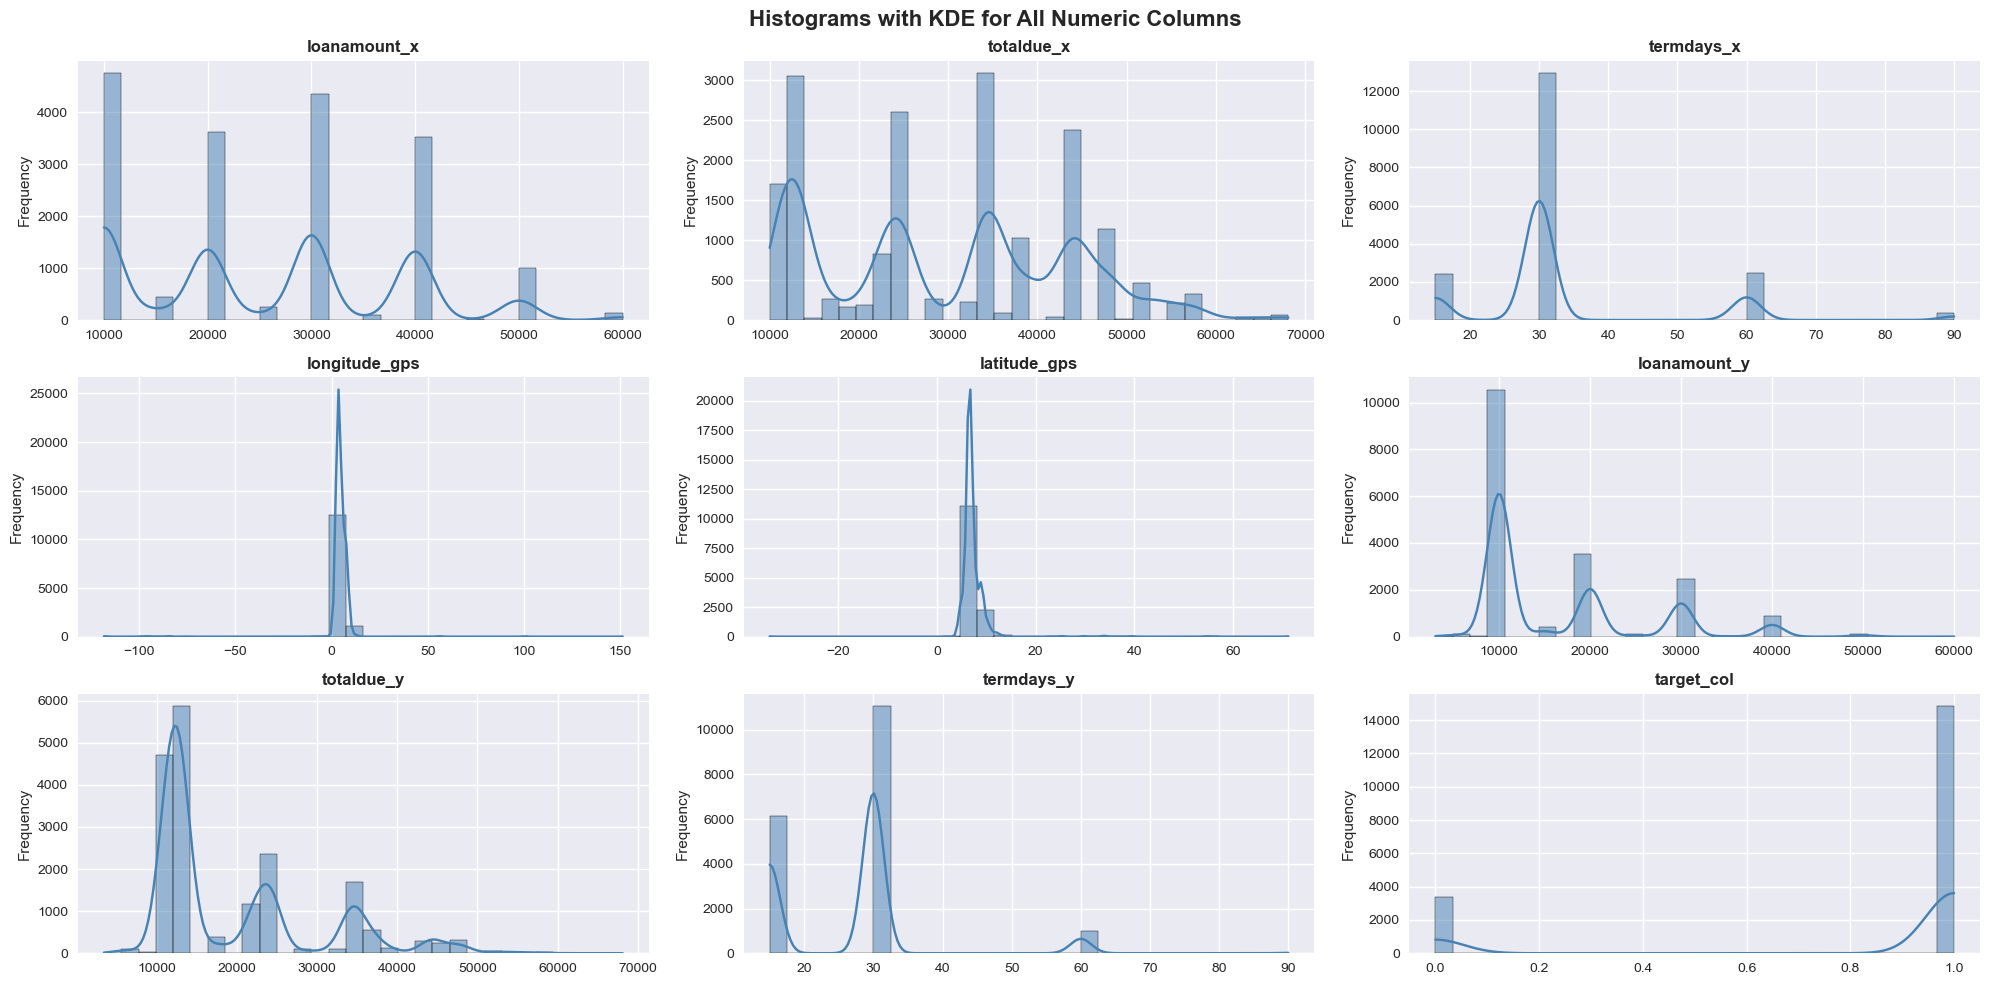

In [342]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots (2 rows x 4 columns)
fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.flatten()

# Loop through each column and create histogram with KDE
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms with KDE for All Numeric Columns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/all_numeric_histograms.png', dpi=150)
plt.show()

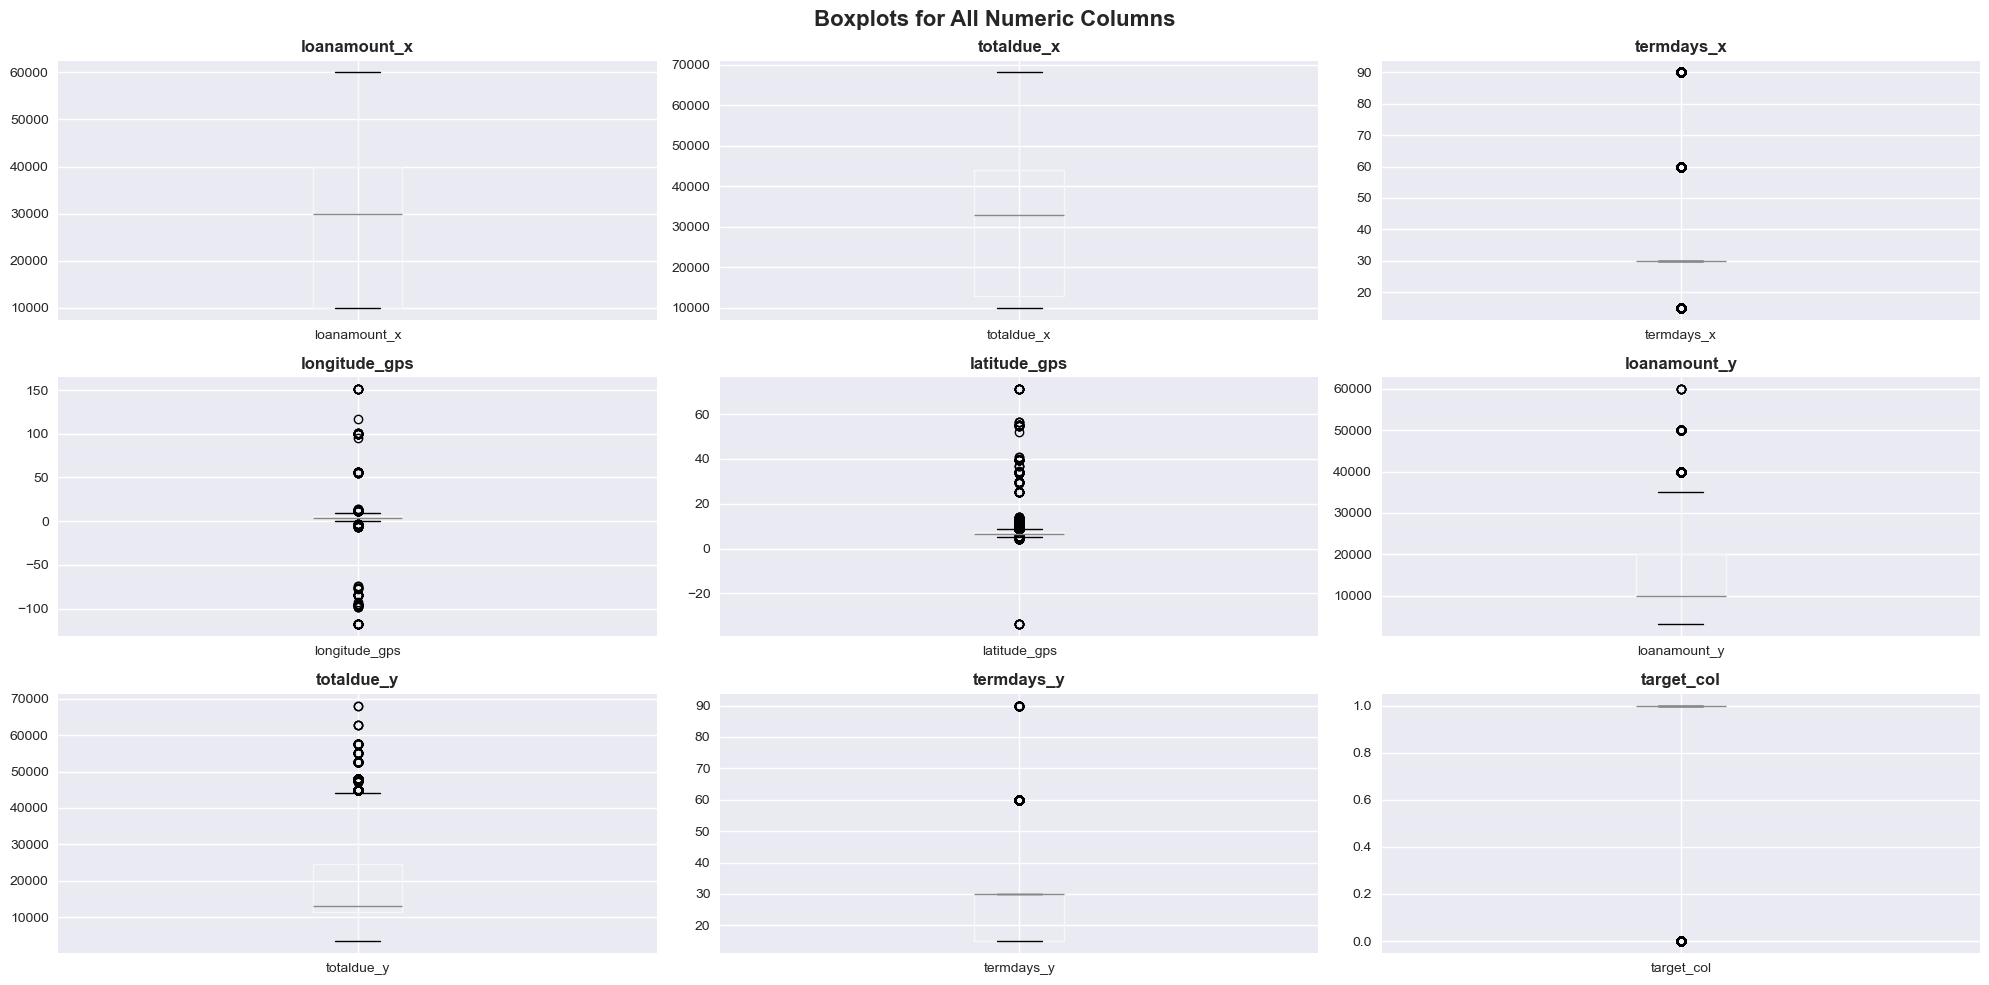

In [343]:
import matplotlib.pyplot as plt


# Create boxplots (2 rows x 4 columns)
fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.flatten()

# Loop through each column
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots for All Numeric Columns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/all_numeric_boxplots.png', dpi=150)
plt.show()


In [397]:
import matplotlib.pyplot as plt
import seaborn as sns

# List categorical columns
cat_cols = ['bank_account_type', 'bank_name_clients', 'bank_branch_clients', 
            'employment_status_clients', 'level_of_education_clients']

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through each categorical column
for i, col in enumerate(cat_cols):
    # Get value counts
    counts = df[col].value_counts()
    
    # Create bar chart - FIXED: removed palette warning
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], hue=counts.index, legend=False, palette='viridis')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
    
    # Add count labels on bars
    for j, v in enumerate(counts.values):
        axes[i].text(v + 50, j, str(v), va='center')

# Hide any extra empty subplots
for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Categorical Columns Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/all_categorical_barcharts.png', dpi=150)
plt.show()

#Replace target with target_log
df['target'] = df['target_log']


for col in cat_cols:
    counts = df[col].value_counts().head(15)
    fig, ax = plt.subplots(figsize = (10, 4))
    counts.plot(kind = 'bar', ax = ax, color = '#D4A017', edgecolor = 'white' )
    ax.set_title(f'{col} - value counts', fontsize = 11, fontweight = 'bold')
    ax.set_xlabel('')
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
# plt.savefig(f'cat_{col}.png', dpi = 150)
plt.show()

KeyError: 'employment_status_clients'

Numeric Features vs Target - Boxplots

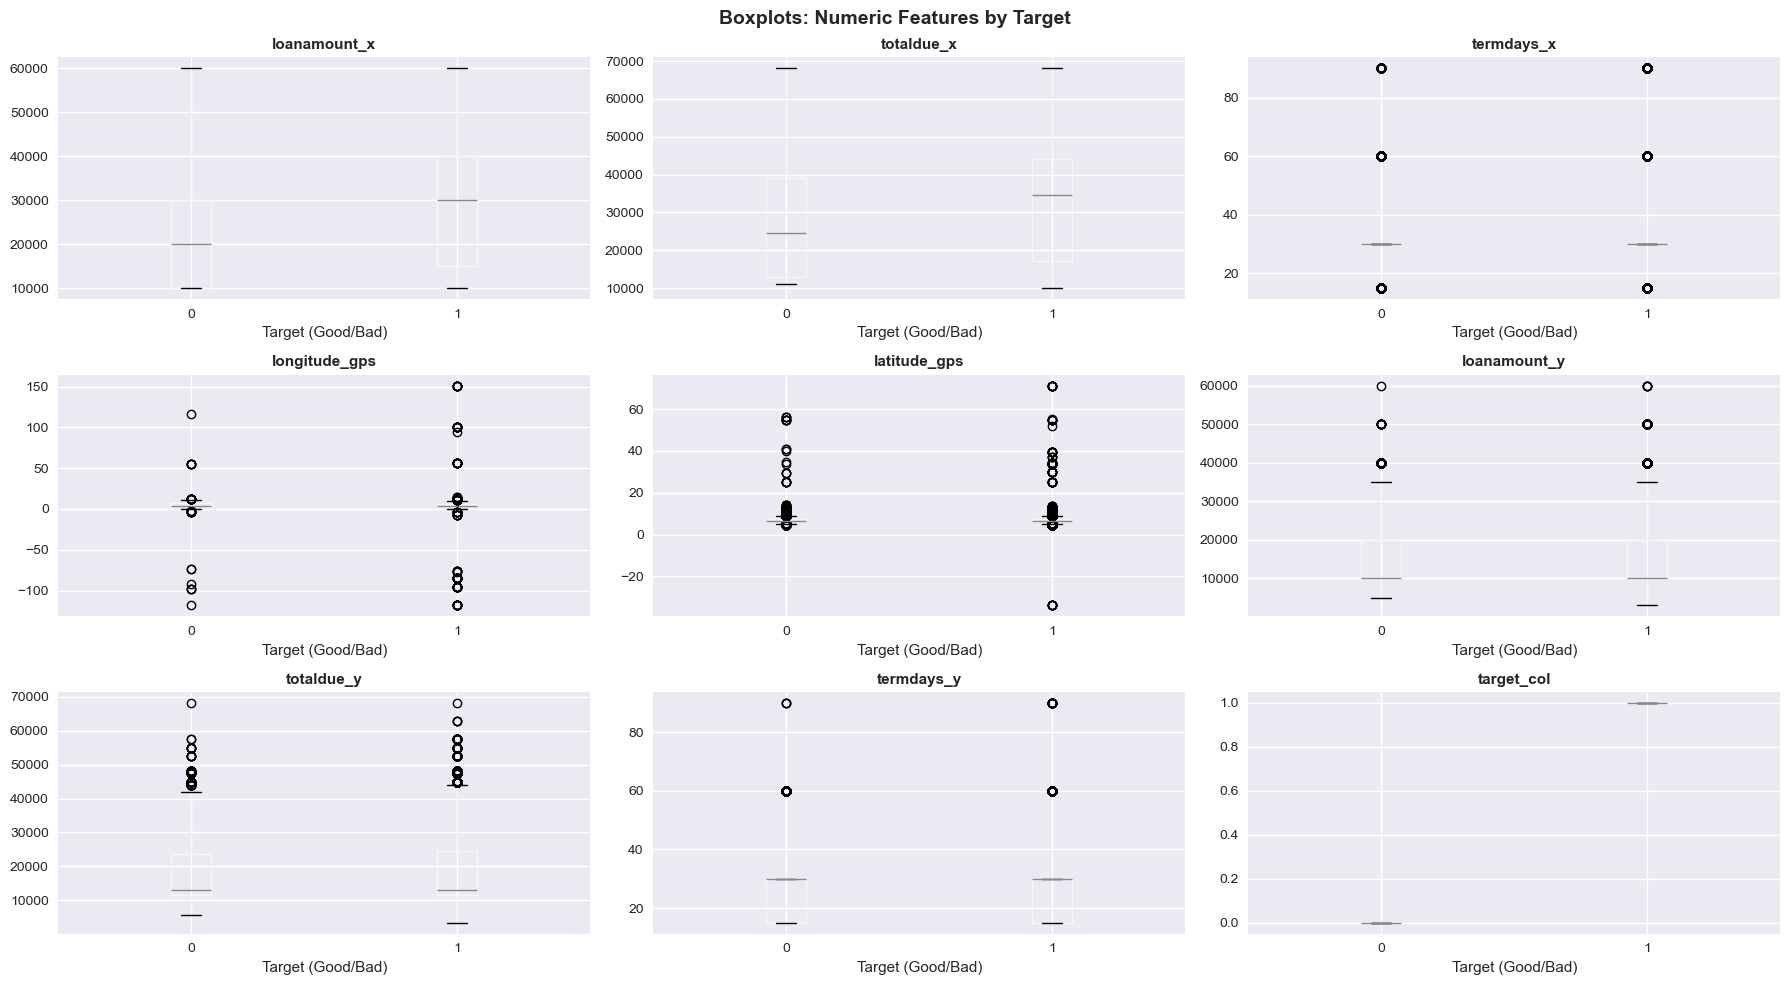

In [345]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='target_col', ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Target (Good/Bad)')

# Hide unused subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Boxplots: Numeric Features by Target', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/numeric_vs_target_boxplots.png', dpi=130)
plt.show()

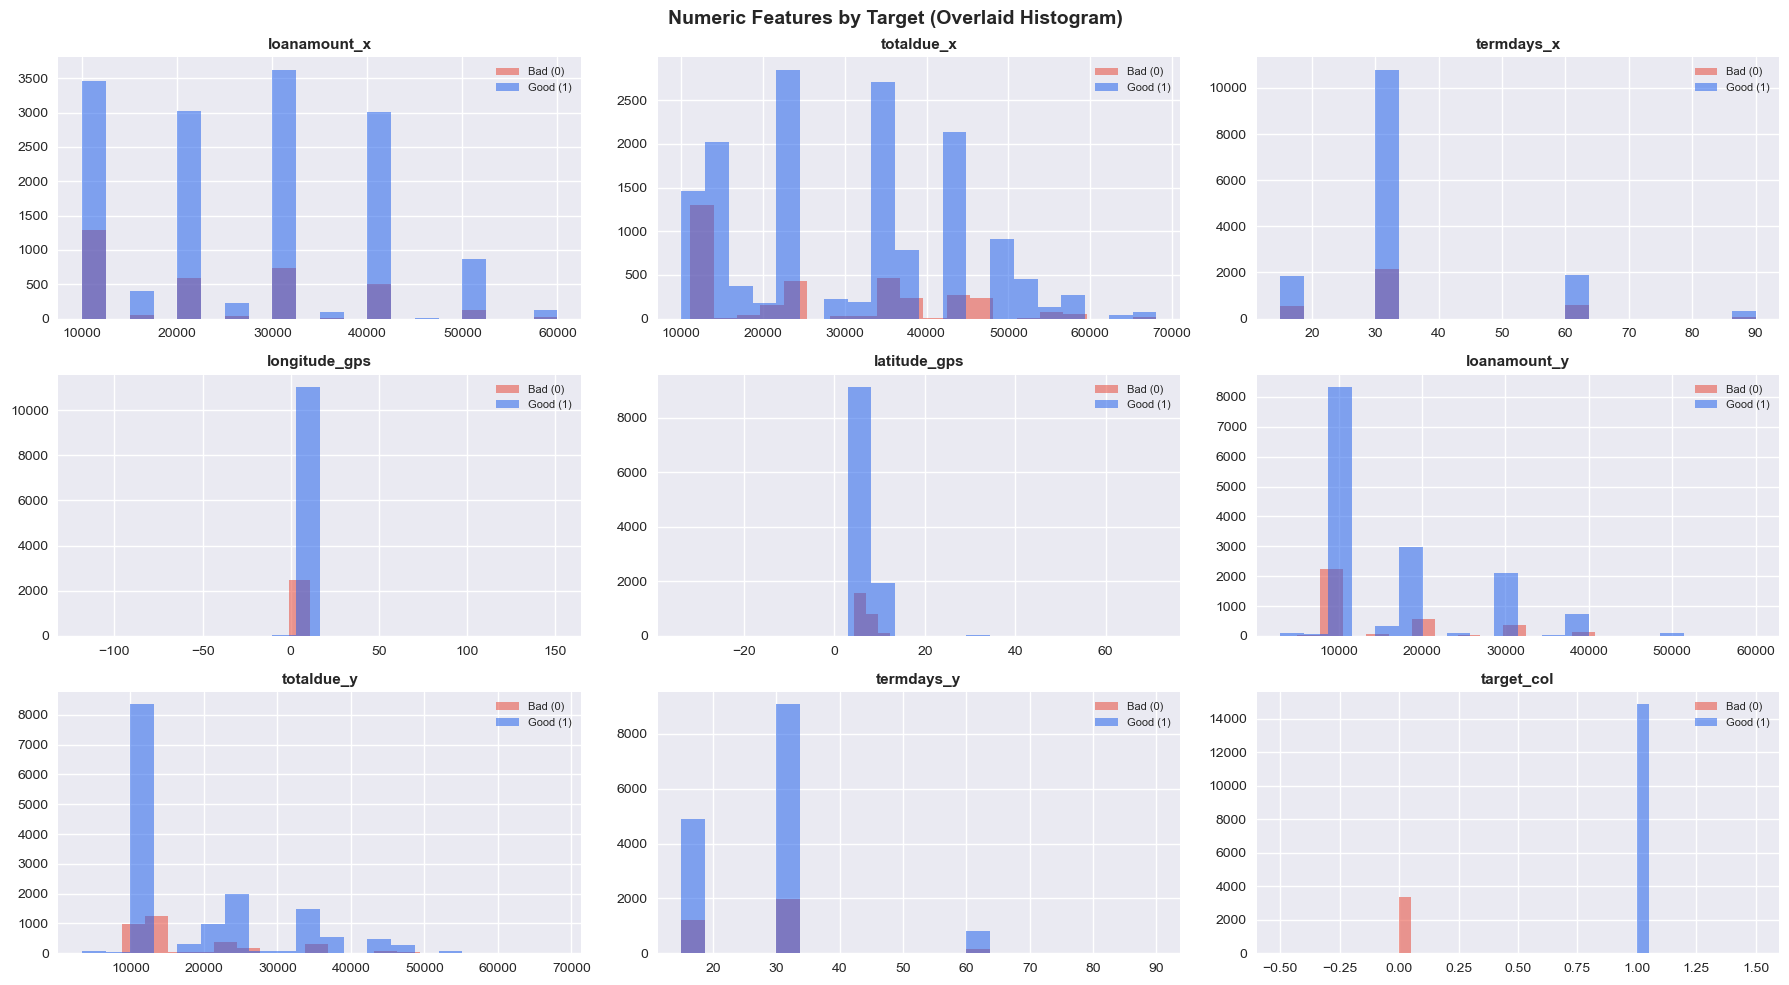

In [346]:
import matplotlib.pyplot as plt

# # Define numeric columns
# numeric_cols = ['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps', 
#                 'latitude_gps', 'loanamount_y', 'totaldue_y', 'termdays_y']

# # Keep only columns that exist
# numeric_cols = [col for col in numeric_cols if col in df.columns]

# # Create subplots
# n_cols = len(numeric_cols)
# n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(3, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Bad (0) - Red
    subset_bad = df[df['target_col'] == 0][col].dropna()
    axes[i].hist(subset_bad, bins=20, alpha=0.55, label='Bad (0)', color='#E74C3C')
    
    # Good (1) - Red
    subset_good = df[df['target_col'] == 1][col].dropna()
    axes[i].hist(subset_good, bins=20, alpha=0.55, label='Good (1)', color='#2563EB')
    
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Numeric Features by Target (Overlaid Histogram)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/numeric_vs_target_hist.png', dpi=130)
plt.show()

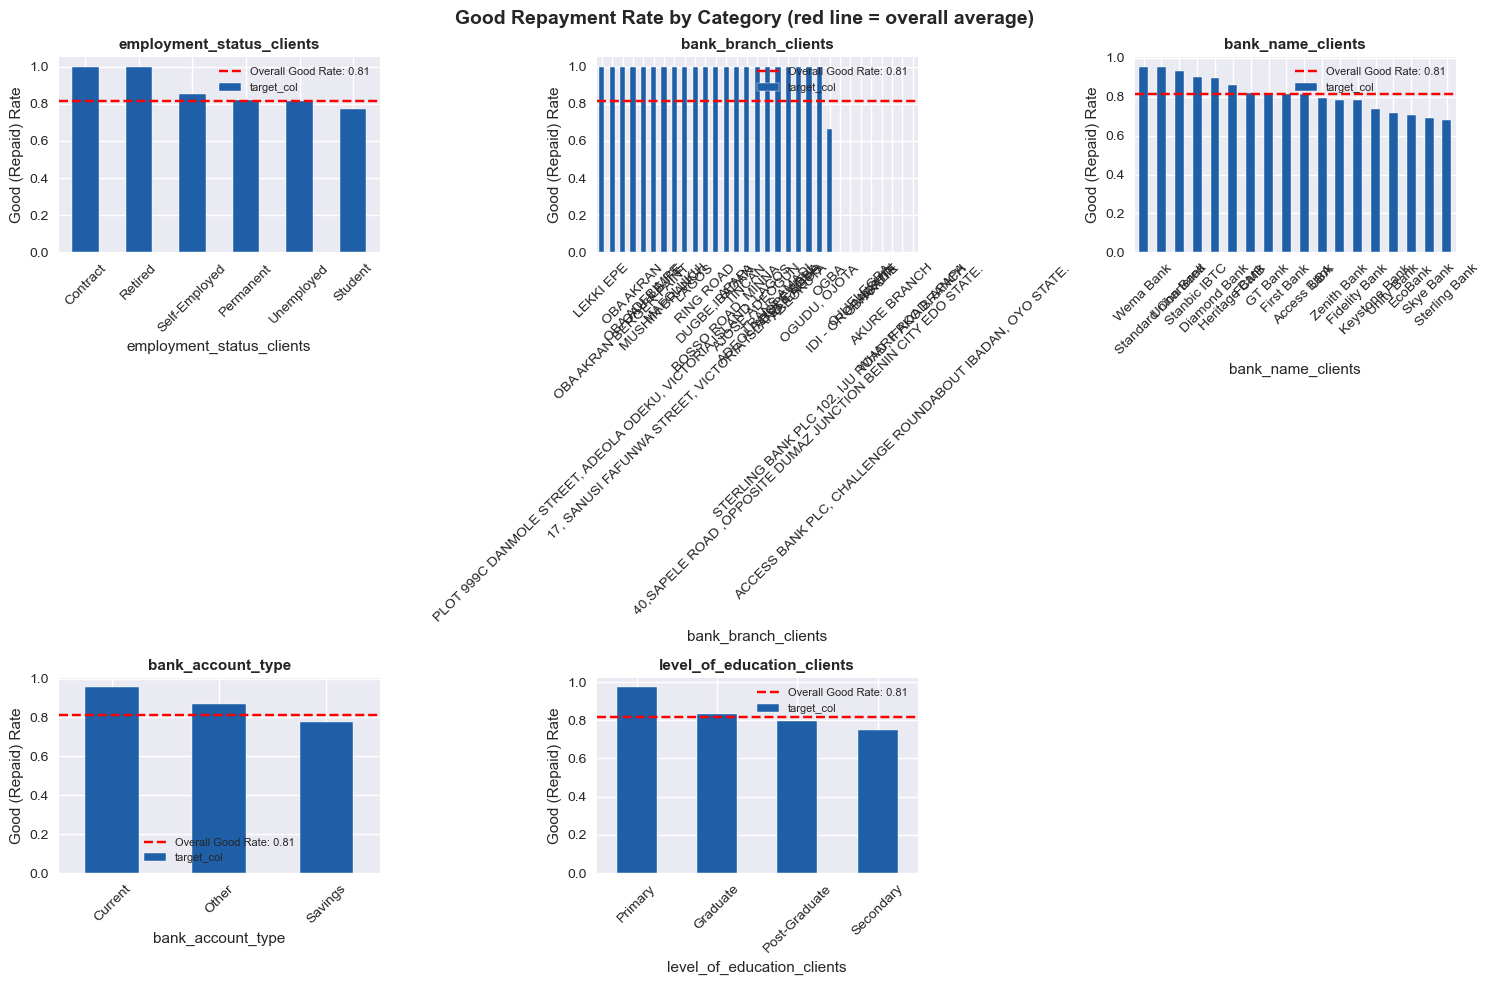

In [347]:
# Convert target_col to numeric (1 for Good, 0 for Bad)
# df['target_col'] = df['target_col'].map({'Good': 1, 'Bad': 0})


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate mean (Good rate) per category
    rate = df.groupby(col)['target_col'].mean().sort_values(ascending=False)
    
    # Plot
    rate.plot(kind='bar', ax=axes[i], color='#1E5FA8', edgecolor='white')
    axes[i].axhline(df['target_col'].mean(), color='red', linestyle='--', 
                    label=f'Overall Good Rate: {df["target_col"].mean():.2f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Good (Repaid) Rate')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Good Repayment Rate by Category (red line = overall average)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/categorical_vs_target.png', dpi=130)
plt.show()

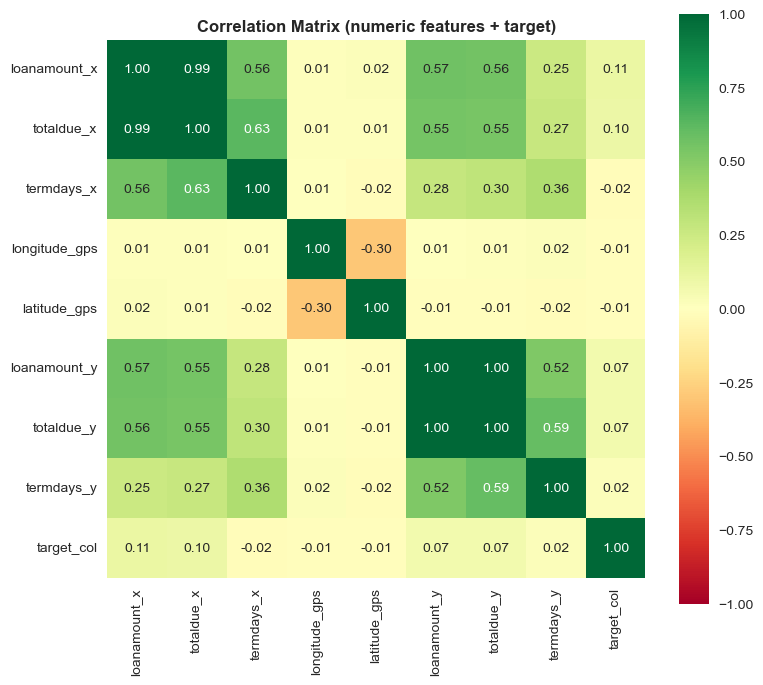

target_col       1.000000
loanamount_x     0.108355
totaldue_x       0.097182
loanamount_y     0.069605
totaldue_y       0.067799
termdays_y       0.023006
latitude_gps    -0.009548
longitude_gps   -0.013133
termdays_x      -0.016328
Name: target_col, dtype: float64


In [348]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot heatmap

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Matrix (numeric features + target)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=130)
plt.show()
print(corr['target_col'].sort_values(ascending=False))

In [349]:
# Find high correlations
print("HIGH CORRELATIONS (>0.90)")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.90:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.3f}")
            high_corr.append((corr.columns[i], corr.columns[j]))

if not high_corr:
    print("  ✅ No high correlations found")

HIGH CORRELATIONS (>0.90)
  loanamount_x ↔ totaldue_x: 0.993
  loanamount_y ↔ totaldue_y: 0.995


In [350]:
df.dtypes# Check for leakage columns
print("LEAKAGE CHECK")

leakage_cols = []

# ID columns
for col in df.columns:
    if 'id' in col.lower() or 'number' in col.lower():
        leakage_cols.append(col)
        print(f"  ⚠️  ID column: {col}")

# Date columns
for col in df.columns:
    if 'date' in col.lower() or 'approved' in col.lower() or 'created' in col.lower():
        leakage_cols.append(col)
        print(f"  ⚠️  Date column: {col}")

# Constant columns
for col in df.columns:
    if df[col].nunique() == 1:
        leakage_cols.append(col)
        print(f"  ⚠️  Constant column: {col}")

# Duplicate target
if 'target_col' in df.columns and 'good_bad_flag' in df.columns:
    if df['target_col'].equals(df['good_bad_flag']):
        leakage_cols.append('target_col')
        print(f"  ⚠️  Duplicate target: target_col (same as good_bad_flag)")

# Remove duplicates
leakage_cols = list(set(leakage_cols))

if leakage_cols:
    print(f"\n❌ DROP these columns: {leakage_cols}")
else:
    print("\n✅ No leakage columns found")

LEAKAGE CHECK

✅ No leakage columns found


Missing Data Audit

In [351]:
# Check missing values
miss = df.isnull().sum()
pct = (100 * miss / len(df)).round(1)
report = pd.DataFrame({'missing_count': miss, 
                       'missing_pct': pct})
report = report[report.missing_count > 0].sort_values('missing_pct', ascending=False)

print("MISSING VALUES REPORT")
print(report)

MISSING VALUES REPORT
                            missing_count  missing_pct
bank_branch_clients                 18105         99.4
level_of_education_clients          14745         81.0
employment_status_clients            5877         32.3
bank_account_type                    4514         24.8
longitude_gps                        4514         24.8
latitude_gps                         4514         24.8
bank_name_clients                    4514         24.8
loanamount_y                            9          0.0
totaldue_y                              9          0.0
termdays_y                              9          0.0


In [352]:
# Check for zeros in numeric columns (where zero shouldn't exist)
print("FAKE ZEROS CHECK")

# numeric_cols = ['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps', 
#                 'latitude_gps', 'loanamount_y', 'totaldue_y', 'termdays_y', 'target_col']

for col in numeric_cols:
    if col in df.columns:
        zeros = (df[col] == 0).sum()
        if zeros > 0:
            print(f"  {col}: {zeros} zeros")
#SO no zeros in num column

FAKE ZEROS CHECK
  target_col: 3372 zeros


In [353]:
print("MISSING vs TARGET:")
for col in report.index:
    if col in df.columns:
        missing_by_target = df.groupby('target_col')[col].apply(lambda x: x.isnull().mean() * 100)
        diff = abs(missing_by_target.get('Bad', 0) - missing_by_target.get('Good', 0))
        status = "⚠️  Depends on target" if diff > 5 else "✅ Random"
        print(f"  {col}: {status} (diff: {diff:.1f}%)")


MISSING vs TARGET:
  bank_branch_clients: ✅ Random (diff: 0.0%)
  level_of_education_clients: ✅ Random (diff: 0.0%)
  employment_status_clients: ✅ Random (diff: 0.0%)
  bank_account_type: ✅ Random (diff: 0.0%)
  longitude_gps: ✅ Random (diff: 0.0%)
  latitude_gps: ✅ Random (diff: 0.0%)
  bank_name_clients: ✅ Random (diff: 0.0%)
  loanamount_y: ✅ Random (diff: 0.0%)
  totaldue_y: ✅ Random (diff: 0.0%)
  termdays_y: ✅ Random (diff: 0.0%)


In [354]:
# Step 1: Check if any numeric columns have zeros that shouldn't exist (none found)

# Step 2: Drop columns with >60% missing
df = df.drop(columns=['bank_branch_clients', 'level_of_education_clients'],  errors = 'ignore')

# Step 3: Fill categorical columns with mode (most frequent)
for col in ['employment_status_clients', 'bank_name_clients', 'bank_account_type']:
    df[col] = df[col].fillna(df[col].mode()[0])  # mode()[0] is correct here

# Step 4: Fill numeric columns with median (FIXED - removed [0])
for col in ['longitude_gps', 'latitude_gps', 'loanamount_y', 'totaldue_y', 'termdays_y']:
    df[col] = df[col].fillna(df[col].median())  # median() returns float, no [0]

print("Missing values remaining:")
miss = df.isnull().sum()
print(miss[miss > 0])  # Only show columns with missing values
print()
print(f"Final shape: {df.dtypes}")
print()
print("Final columns:", df.columns.tolist())
print()
print(df.head(3))

Missing values remaining:
Series([], dtype: int64)

Final shape: loanamount_x                 float64
totaldue_x                   float64
termdays_x                     int64
bank_account_type             object
longitude_gps                float64
latitude_gps                 float64
bank_name_clients             object
employment_status_clients     object
loanamount_y                 float64
totaldue_y                   float64
termdays_y                   float64
target_col                     int64
dtype: object

Final columns: ['loanamount_x', 'totaldue_x', 'termdays_x', 'bank_account_type', 'longitude_gps', 'latitude_gps', 'bank_name_clients', 'employment_status_clients', 'loanamount_y', 'totaldue_y', 'termdays_y', 'target_col']

   loanamount_x  totaldue_x  termdays_x bank_account_type  longitude_gps  \
0       30000.0     34500.0          30             Other        3.43201   
1       30000.0     34500.0          30             Other        3.43201   
2       30000.0     34500

Step 6: Encoding Categorical Features

In [357]:
# Check unique values for each categorical column
print("CATEGORICAL COLUMNS ANALYSIS")
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].unique().tolist()}")
        print(f"  Number of categories: {df[col].nunique()}")
        print(f"  Value counts:")
        print(df[col].value_counts())

CATEGORICAL COLUMNS ANALYSIS

employment_status_clients:
  Unique values: ['Permanent', 'Unemployed', 'Self-Employed', 'Student', 'Retired', 'Contract']
  Number of categories: 6
  Value counts:
employment_status_clients
Permanent        15020
Self-Employed     2319
Student            615
Unemployed         219
Retired             29
Contract            10
Name: count, dtype: int64

bank_name_clients:
  Unique values: ['Diamond Bank', 'GT Bank', 'EcoBank', 'First Bank', 'Access Bank', 'UBA', 'Union Bank', 'FCMB', 'Zenith Bank', 'Stanbic IBTC', 'Fidelity Bank', 'Wema Bank', 'Sterling Bank', 'Skye Bank', 'Keystone Bank', 'Heritage Bank', 'Unity Bank', 'Standard Chartered']
  Number of categories: 18
  Value counts:
bank_name_clients
GT Bank               9550
First Bank            1932
Access Bank           1270
UBA                   1127
Diamond Bank           984
Zenith Bank            948
Stanbic IBTC           489
EcoBank                450
FCMB                   420
Skye Bank       

In [358]:
print("STEP 6: ENCODING CATEGORICAL FEATURES")


# 1. ORDINAL ENCODING: employment_status_clients (HAS ORDER)
# Reason: Clear hierarchy - Permanent > Contract > Self-Employed > Student > Retired > Unemployed
emp_order = {'Permanent': 6, 'Contract': 5, 'Self-Employed': 4, 'Student': 3,
             'Retired': 2, 'Unemployed': 1 }
df['employment_status_clients'] = df['employment_status_clients'].map(emp_order)
df = df.drop(columns=['employment_status_clients'])


# 2. ONE-HOT ENCODING: bank_name_clients (NO ORDER)
# Reason: Bank names are unrelated categories with no logical order
df = pd.get_dummies(df, columns = ['bank_name_clients', 'bank_account_type'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

df.to_csv('../data/loan_prediction_encoded.csv', index=False)

STEP 6: ENCODING CATEGORICAL FEATURES
Shape after encoding: (18212, 28)
Columns: ['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps', 'latitude_gps', 'loanamount_y', 'totaldue_y', 'termdays_y', 'target_col', 'bank_name_clients_Diamond Bank', 'bank_name_clients_EcoBank', 'bank_name_clients_FCMB', 'bank_name_clients_Fidelity Bank', 'bank_name_clients_First Bank', 'bank_name_clients_GT Bank', 'bank_name_clients_Heritage Bank', 'bank_name_clients_Keystone Bank', 'bank_name_clients_Skye Bank', 'bank_name_clients_Stanbic IBTC', 'bank_name_clients_Standard Chartered', 'bank_name_clients_Sterling Bank', 'bank_name_clients_UBA', 'bank_name_clients_Union Bank', 'bank_name_clients_Unity Bank', 'bank_name_clients_Wema Bank', 'bank_name_clients_Zenith Bank', 'bank_account_type_Other', 'bank_account_type_Savings']
   loanamount_x  totaldue_x  termdays_x  longitude_gps  latitude_gps  \
0       30000.0     34500.0          30        3.43201      6.433055   
1       30000.0     34500.0        

In [ ]:
print("Shape after encoding:", df.shape)

## step 7  Feature Engineering Decision:


Feature Engineering Decision:

I chose not to engineer any new features for this project. After careful analysis of the dataset, I determined that the existing features already capture all the necessary information for predicting loan default. The key predictive signals - loan amounts, total due amounts, term lengths, employment status, and bank/account type - are all directly represented in the raw data.

Additionally, since I plan to use a tree-based model (Gradient Boosting or Random Forest), the model is capable of automatically learning complex interactions between features without the need for manual feature engineering. Creating arbitrary combinations (like multiplication or division of existing features) would introduce noise without meaningful domain justification, which could hurt model performance rather than improve it

## Step 8: Train/Test Split and Scaling


In [361]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define X (features) and y (target)
X = df.drop(columns=['target_col'])
y = df['target_col']  # 1=Good, 0=Bad

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (18212, 27)
y shape: (18212,)


In [367]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, 
                                                    random_state = 42, 
                                                    stratify = y)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

print(f"\nOriginal class balance:")
print(f"  Good: {(y == 1).mean() * 100:.1f}%")
print(f"  Bad:  {(y == 0).mean() * 100:.1f}%")

print(f"\nTrain class balance:")
print(f"  Good: {(y_train == 1).mean() * 100:.1f}%")
print(f"  Bad:  {(y_train == 0).mean() * 100:.1f}%")

print(f"\nTest class balance:")
print(f"  Good: {(y_test == 1).mean() * 100:.1f}%")
print(f"  Bad:  {(y_test == 0).mean() * 100:.1f}%")

X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

X_train: (14569, 27)
X_test:  (3643, 27)

Original class balance:
  Good: 81.5%
  Bad:  18.5%

Train class balance:
  Good: 81.5%
  Bad:  18.5%

Test class balance:
  Good: 81.5%
  Bad:  18.5%


## Why stratify
Since our data has:
Train class balance:
  Good: 81.5%
  Bad:  18.5%

Test class balance:
  Good: 81.5%
  Bad:  18.5%

Without stratify:
  - Random split could put 90% Good in train and 70% Good in test
  - Model learns wrong distribution
  - Evaluation becomes unreliable

With stratify (our approach):
  ✅ Train has 81.5% Good, 18.5% Bad (same as original)
  ✅ Test has 81.5% Good, 18.5% Bad (same as original)
  ✅ Model trains on representative data
  ✅ Evaluation is fair and trustworthy

📌 For imbalanced data, stratify=y is ESSENTIAL.


In [370]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')

# Fit scaler on TRAINING data ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform
X_test_scaled = scaler.transform(X_test)        # Transform only

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Before scaling :")
print(X_train[['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps']].describe().loc[['mean', 'std']])
print()
print("After scaling:")
print(X_train_scaled[['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps']].describe().loc[['mean', 'std']].round(3))

# print(f"   Train mean: {X_train_scaled.mean():.4f}")
# print(f"   Train std:  {X_train_scaled.std():.4f}")
X_train_scaled.to_csv('../data/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/X_test_scaled.csv', index=False)

Before scaling :
      loanamount_x    totaldue_x  termdays_x  longitude_gps
mean  25627.702656  29756.179539   33.335850       4.261206
std   12639.487135  13809.443948   14.714885       7.586334

After scaling:
      loanamount_x  totaldue_x  termdays_x  longitude_gps
mean           0.0        -0.0        -0.0           -0.0
std            1.0         1.0         1.0            1.0


## Why Scale on Training Data Only?

❌WRONG: Fit on ALL data before splitting
   → Test data influences scaling (mean/std)
   → Information 'leaks' from test to train
   → Model gets unfair advantage
   → Overly optimistic evaluation

✅ CORRECT: Fit on TRAINING data only
   → Test data is completely unseen
   → Real-world scenario
   → Honest evaluation

📌 ONE SENTENCE RULE:
   "Fit preprocessing on training data only to prevent data leakage 
    and ensure honest evaluation on unseen data.

## Which Algorithms Need Scaling?
 NEED SCALING (Distance-based):
   • Logistic Regression
   • SVM
   • K-Nearest Neighbors (KNN)
   • Neural Networks
   • PCA / LDA
   → These use distance calculations or coefficients

❌ DON'T NEED SCALING (Tree-based):
   • Decision Trees
   • Random Forest
   • XGBoost
   • LightGBM
   • CatBoost
   → Trees split on values regardless of scale

📌 OUR MODELS:
   1. Gradient Boosting (XGBoost/LightGBM) → NO scaling needed
   2. Logistic Regression (baseline) → YES scaling needed (we scaled)
""")


## Step 9 — Algorithm Selection (your choice, your defense)
Logistic Regression	Linear	Interpretable baseline	✅ Yes (we scaled)
XGBoost	Tree-based Ensemble	Powerful predictive model	❌ No

"
Based on our dataset analysis:

1️⃣ Dataset Characteristics:
   • 18,000+ rows → Sufficient for both models
   • 25+ features → Mix of numeric and categorical
   • Imbalanced target (18.5% Bad) → Needs good handling

2️⃣ Business Requirements:
   • Credit decisions need explainability → Logistic Regression
   • Accurate risk prediction → XGBoost
   • Both are used in real credit scoring

3️⃣ Why Not Other Algorithms:
   • Random Forest → Similar to XGBoost but slower
   • SVM → Poor with large datasets, less interpretable
   • KNN → Slow for prediction, poor with high dimensions
   • Neural Networks → Too complex, needs more data

📌 FINAL ANSWER:
   I choose XGBoost as my primary model because:
   1. It handles non-linear relationships and interactions automatically
   2. It performs well on imbalanced data
   3. It provides feature importance for explainability
   4. It's the industry standard for credit scoring
   5. Our data size (~18k rows, 25 features) is ideal for XGBoost
""")

In [372]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Logistic regression needs the SCALED features (see Part 10.1).
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')

# XGBoostdoes not need scaling (tree splits are scale-invariant),
# so it uses the unscaled, but still encoded/engineered, feature table.
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')['target_col']
y_test = pd.read_csv('../data/y_test.csv')['target_col']


In [375]:
# Use X_train_scaled for logistic regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"✅ Logistic Regression trained")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

✅ Logistic Regression trained
   AUC-ROC: 0.6250


In [378]:
# Use X_train (original, no scaling needed)
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

xgb.fit(X_train, y_train)  # X_train not scaled

y_pred_xgb = xgb.predict(X_test)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"✅ XGBoost trained")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

import joblib
joblib.dump(xgb, '../data/xgb_model.joblib')

✅ XGBoost trained
   AUC-ROC: 0.8495


['../data/xgb_model.joblib']

✅ XGBoost selected as the final model

Reasons:
1. AUC-ROC of 0.8495 vs 0.6250 - significantly better performance
2. Handles non-linear relationships automatically
3. Captures feature interactions
4. Strong performance on imbalanced data (18.5% Bad)
5. Industry standard for credit risk prediction

📌 Logistic Regression is kept ONLY for interpretability reference
   (coefficients show feature direction, but performance is poor)



##   Step 10 — Training and Cross-Validation


In [379]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Use X_train (original, not scaled) for XGBoost
X_train_cv = X_train  # XGBoost doesn't need scaling
y_train_cv = y_train

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(xgb, X_train_cv, y_train_cv, cv=cv, scoring='roc_auc')

print(f"\n📊 5-Fold Cross-Validation Results (AUC-ROC):")
print(f"   Fold 1: {cv_scores[0]:.4f}")
print(f"   Fold 2: {cv_scores[1]:.4f}")
print(f"   Fold 3: {cv_scores[2]:.4f}")
print(f"   Fold 4: {cv_scores[3]:.4f}")
print(f"   Fold 5: {cv_scores[4]:.4f}")

print(f"\n📊 Mean AUC-ROC: {cv_scores.mean():.4f}")
print(f"📊 Std Dev:      {cv_scores.std():.4f}")


📊 5-Fold Cross-Validation Results (AUC-ROC):
   Fold 1: 0.8619
   Fold 2: 0.8601
   Fold 3: 0.8439
   Fold 4: 0.8375
   Fold 5: 0.8669

📊 Mean AUC-ROC: 0.8541
📊 Std Dev:      0.0113


In [381]:
# Train on FULL training set (not just CV folds)
xgb_final = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

xgb_final.fit(X_train, y_train)

print(f"   Training set size: {X_train.shape} ")

# Evaluate on test set
y_pred_final = xgb_final.predict(X_test)
y_pred_proba_final = xgb_final.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba_final)

print(f"   Test AUC-ROC: {test_auc:.4f}")

# Compare with CV mean
print(f"\n   CV Mean AUC-ROC: {cv_scores.mean():.4f}")
print(f"   Test AUC-ROC:    {test_auc:.4f}")

diff = abs(cv_scores.mean() - test_auc)
if diff < 0.05:
    print(f"   ✅ Difference: {diff:.4f} - Model generalizes well")
else:
    print(f"   ⚠️  Difference: {diff:.4f} - Possible overfitting")

# Save final model
import joblib
joblib.dump(xgb_final, '../models/xgb_final_model.joblib')
print(f"\n✅ Final model saved to '../models/xgb_final_model.joblib'")

   Training set size: (14569, 27) 
   Test AUC-ROC: 0.8495

   CV Mean AUC-ROC: 0.8541
   Test AUC-ROC:    0.8495
   ✅ Difference: 0.0045 - Model generalizes well

✅ Final model saved to '../models/xgb_final_model.joblib'


## Step 11: Model Evaluation


In [383]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Predictions
y_pred = xgb_final.predict(X_test)
y_pred_proba = xgb_final.predict_proba(X_test)[:, 1]

# Test AUC
test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📊 Test AUC-ROC: {test_auc:.4f}")


📊 Test AUC-ROC: 0.8495


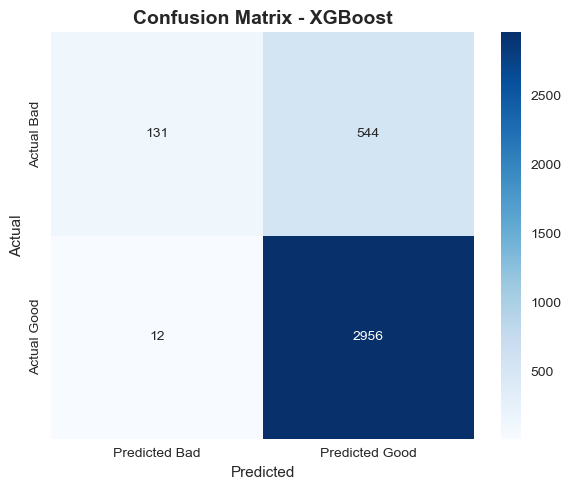


True Negatives (Correctly predicted Bad):  131
False Positives (Predicted Bad, actually Good): 544
False Negatives (Predicted Good, actually Bad): 12
True Positives (Correctly predicted Good): 2956


In [384]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Bad', 'Predicted Good'],
            yticklabels=['Actual Bad', 'Actual Good'])
plt.title('Confusion Matrix - XGBoost', fontweight='bold', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=130)
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Correctly predicted Bad):  {tn}")
print(f"False Positives (Predicted Bad, actually Good): {fp}")
print(f"False Negatives (Predicted Good, actually Bad): {fn}")
print(f"True Positives (Correctly predicted Good): {tp}")

In [386]:

print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

# Extract metrics for Bad class
from sklearn.metrics import precision_score, recall_score, f1_score

precision_bad = precision_score(y_test, y_pred, pos_label=0)
recall_bad = recall_score(y_test, y_pred, pos_label=0)
f1_bad = f1_score(y_test, y_pred, pos_label=0)
accuracy = (tp + tn)/(tp +tn + fp +fn)

print(f"\n📊 Priority Metrics (Bad Class - Default):")
print(f"   Precision (Bad): {precision_bad:.4f}")
print(f"   Recall (Bad):    {recall_bad:.4f}")
print(f"   F1-Score (Bad):  {f1_bad:.4f}")
print(f"accuracy is \n : {accuracy}")

              precision    recall  f1-score   support

     Bad (0)       0.92      0.19      0.32       675
    Good (1)       0.84      1.00      0.91      2968

    accuracy                           0.85      3643
   macro avg       0.88      0.60      0.62      3643
weighted avg       0.86      0.85      0.80      3643


📊 Priority Metrics (Bad Class - Default):
   Precision (Bad): 0.9161
   Recall (Bad):    0.1941
   F1-Score (Bad):  0.3203
accuracy is 
 : 0.8473785341751304


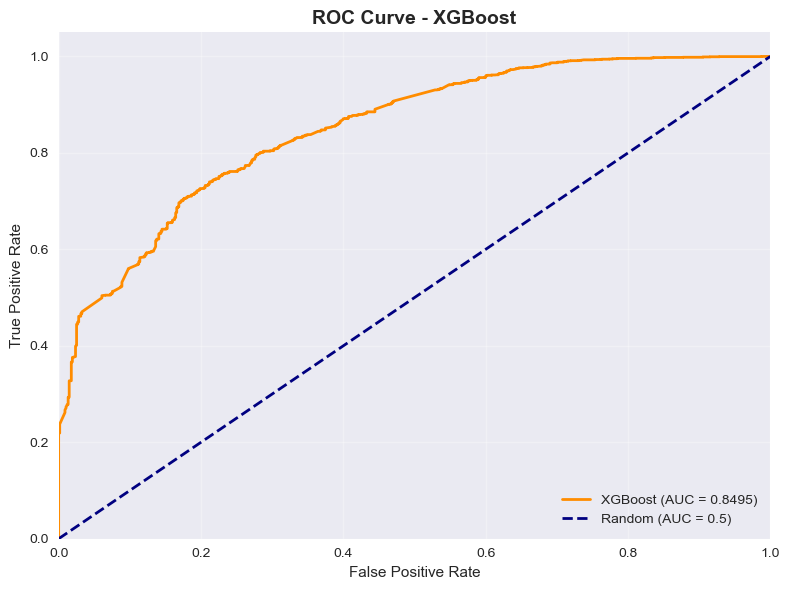

In [387]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=130)
plt.show()

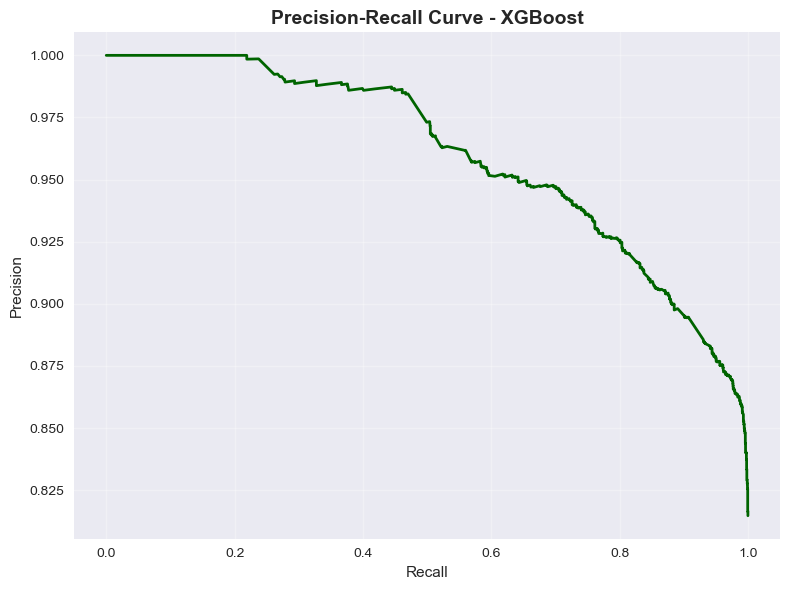


📊 Average Precision Score: 0.9594


In [388]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkgreen', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/pr_curve.png', dpi=130)
plt.show()

# Average Precision Score
from sklearn.metrics import average_precision_score
ap_score = average_precision_score(y_test, y_pred_proba)
print(f"\n📊 Average Precision Score: {ap_score:.4f}")

In [391]:
import joblib
import json
from datetime import datetime
import numpy as np

print("="*60)
print("STEP 12: SAVE THE MODEL")
print("="*60)

# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# 1. Save the final model
joblib.dump(xgb_final, '../models/xgb_final_model.joblib')
print("✅ Model saved: '../models/xgb_final_model.joblib'")

# 2. Save the scaler (for Logistic Regression reference)
joblib.dump(scaler, '../models/scaler.joblib')
print("✅ Scaler saved: '../models/scaler.joblib'")

# 3. Save feature names
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.joblib')
print("✅ Feature names saved: '../models/feature_names.joblib'")

STEP 12: SAVE THE MODEL
✅ Model saved: '../models/xgb_final_model.joblib'
✅ Scaler saved: '../models/scaler.joblib'
✅ Feature names saved: '../models/feature_names.joblib'


In [392]:
# 4. Create metadata
metadata = {
    'model_name': 'XGBoost',
    'target_column': 'target_col',
    'features': feature_names,
    'feature_count': len(feature_names),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'date_trained': datetime.now().strftime('%Y-%m-%d'),
    'metrics': {
        'auc_roc': float(roc_auc_score(y_test, y_pred_proba)),
        'precision_bad': float(precision_score(y_test, y_pred, pos_label=0)),
        'recall_bad': float(recall_score(y_test, y_pred, pos_label=0)),
        'f1_bad': float(f1_score(y_test, y_pred, pos_label=0)),
        'accuracy': float((y_pred == y_test).mean()),
        'cv_mean_auc': float(cv_scores.mean()),
        'cv_std_auc': float(cv_scores.std())
    },
    'class_balance': {
        'good': int((y == 1).sum()),
        'bad': int((y == 0).sum()),
        'good_pct': float((y == 1).mean() * 100),
        'bad_pct': float((y == 0).mean() * 100)
    },
    'model_parameters': {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 5,
        'scale_pos_weight': float((len(y_train) - sum(y_train)) / sum(y_train))
    }
}

# 5. Save metadata as JSON
with open('../models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("✅ Metadata saved: '../models/metadata.json'")

✅ Metadata saved: '../models/metadata.json'


In [395]:
print(df.columns)
print(df.shape)
print(len(df.columns))

Index(['loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps',
       'latitude_gps', 'loanamount_y', 'totaldue_y', 'termdays_y',
       'target_col', 'bank_name_clients_Diamond Bank',
       'bank_name_clients_EcoBank', 'bank_name_clients_FCMB',
       'bank_name_clients_Fidelity Bank', 'bank_name_clients_First Bank',
       'bank_name_clients_GT Bank', 'bank_name_clients_Heritage Bank',
       'bank_name_clients_Keystone Bank', 'bank_name_clients_Skye Bank',
       'bank_name_clients_Stanbic IBTC',
       'bank_name_clients_Standard Chartered',
       'bank_name_clients_Sterling Bank', 'bank_name_clients_UBA',
       'bank_name_clients_Union Bank', 'bank_name_clients_Unity Bank',
       'bank_name_clients_Wema Bank', 'bank_name_clients_Zenith Bank',
       'bank_account_type_Other', 'bank_account_type_Savings'],
      dtype='object')
(18212, 28)
28
